# Effective Class Distribution After Sampling

Notebook này chỉ tập trung vào một câu hỏi: sau khi áp sampler, oversampling và xử lý ảnh rỗng thì phân bố dữ liệu theo class thay đổi như thế nào.

Lưu ý: augmentation không đổi nhãn class, nên nó không làm đổi phân bố class. Phần làm thay đổi phân bố thực tế là sampler.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks.notebook_helpers import summarize_effective_class_distribution

sns.set_theme(style="whitegrid")

TRAIN_ANN = REPO_ROOT / "public/annotations/train.json"
TRAIN_IMG = REPO_ROOT / "public/train/images"

SAMPLER_STRATEGY = "class_small_balanced"
OVERSAMPLE_CLASS = "chair"
OVERSAMPLE_FACTOR = 1.5
SMALL_OBJECT_BOOST = 1.5
SMALL_OBJECT_THRESHOLD = 0.01
EMPTY_IMAGE_WEIGHT = 0.5

In [12]:
distribution_df, sampler_info = summarize_effective_class_distribution(
    annotation_path=TRAIN_ANN,
    image_dir=TRAIN_IMG,
    sampler_strategy=SAMPLER_STRATEGY,
    oversample_class=OVERSAMPLE_CLASS,
    oversample_factor=OVERSAMPLE_FACTOR,
    small_object_boost=SMALL_OBJECT_BOOST,
    small_object_threshold=SMALL_OBJECT_THRESHOLD,
    empty_image_weight=EMPTY_IMAGE_WEIGHT,
)

pd.DataFrame([sampler_info])

,enabled,strategy,class,factor,target_images,small_object_boost,small_object_threshold,small_object_images,empty_image_weight,empty_images,total_images,target_image_ratio,min_weight,max_weight,mean_weight
0,True,class_small_balanced,chair,1.5,754,1.5,0.01,644,0.5,2500,7500,0.100533,0.5,5.951919,1.513337


In [13]:
distribution_df

,class,original_objects,expected_sampled_objects,sampling_ratio,expected_sampled_images
0,person,5829,6209.804886,1.065329,2812.497389
1,chair,1613,3438.019523,2.131444,1540.088122
2,car,1339,2344.455802,1.750901,1284.686174
3,dog,1028,1691.759540,1.645680,1408.356240
4,cat,833,1499.338508,1.799926,1326.287488


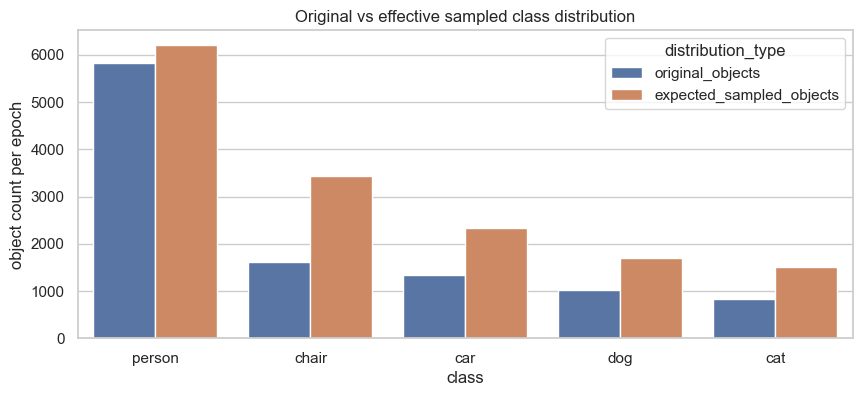

In [14]:
plot_df = distribution_df.melt(
    id_vars="class",
    value_vars=["original_objects", "expected_sampled_objects"],
    var_name="distribution_type",
    value_name="count",
)

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="class", y="count", hue="distribution_type")
plt.title("Original vs effective sampled class distribution")
plt.xlabel("class")
plt.ylabel("object count per epoch")
plt.show()

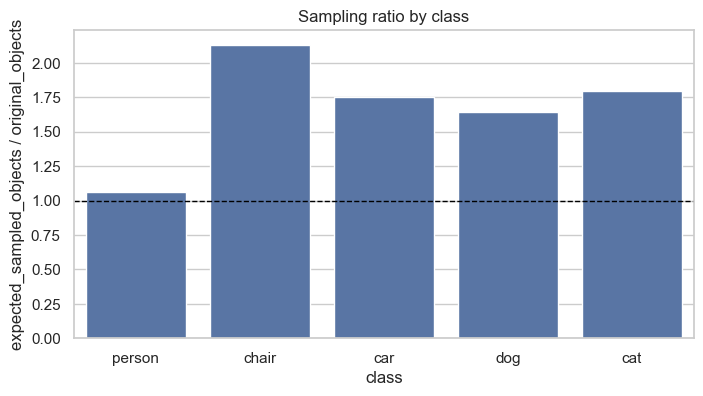

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(data=distribution_df, x="class", y="sampling_ratio")
plt.axhline(1.0, color="black", linestyle="--", linewidth=1)
plt.title("Sampling ratio by class")
plt.xlabel("class")
plt.ylabel("expected_sampled_objects / original_objects")
plt.show()

## Cách đọc

- `original_objects`: số bbox gốc trong train set.
- `expected_sampled_objects`: số bbox kỳ vọng xuất hiện sau 1 epoch sampling.
- `sampling_ratio > 1`: class đó đang được boost.
- `sampling_ratio < 1`: class đó bị giảm tương đối so với dữ liệu gốc.
- Nếu bạn chỉ muốn xem class balancing thuần túy, đặt `OVERSAMPLE_CLASS = None`.